**06-other-explorations**  
Other explorations of the data, to complement existing analyses.

In [28]:
# IMPORTS, PATH, HELPER FUNCTION for the whole notebook, including the core functions to run logistic regression with donor split and optional batch covariates
import os
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()   # change if needed
os.chdir(REPO_ROOT)

# -------------------------
# global settings
# -------------------------
CELLTYPE_COL = "cell_type"
DONOR_COL = "patient_id"
BATCH_COL = "Site"
RANDOM_STATE = 42

REPRESENTATIONS = {
    "hvg": "hvg",
    "pca": "X_pca",
    "harmony": "X_harmony",
    "scvi": "X_scVI",
}

FILTERED_DATA_PATH = "data/adata_filtered_celltypes.h5ad"
FULL_DATA_PATH = "data/adata_full_celltypes.h5ad"

# -------------------------
# helper functions
# -------------------------
def get_representation(adata, rep_name):
    """
    Return feature matrix for a given representation.
    - hvg uses adata.X
    - other representations use adata.obsm[rep_name]
    """
    if rep_name == "hvg":
        X = adata.X
    else:
        X = adata.obsm[rep_name]

    if hasattr(X, "toarray"):
        X = X.toarray()
    else:
        X = np.asarray(X)

    return X


def get_batch_matrix(obs, batch_col):
    """
    One-hot encode batch/site covariate.
    """
    batch_df = pd.get_dummies(
        obs[batch_col].astype(str),
        prefix=batch_col,
        drop_first=False,
    )
    return batch_df.to_numpy(), batch_df.columns.tolist()


def restrict_to_train_labels(y_train, y_test, X_test, obs_test):
    """
    Remove test cells whose labels are absent in training donors.
    This avoids impossible multiclass prediction targets.
    """
    train_labels = set(pd.Series(y_train).astype(str).unique())
    keep_mask = pd.Series(y_test).astype(str).isin(train_labels).to_numpy()

    y_test = np.asarray(y_test)[keep_mask]
    X_test = X_test[keep_mask]
    obs_test = obs_test.loc[keep_mask].copy()

    return y_test, X_test, obs_test


def save_confusion_matrix(cm, labels, out_file, title, normalize=False):
    """
    Save confusion matrix plot.
    """
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(
            cm.astype(float),
            row_sums,
            out=np.zeros_like(cm, dtype=float),
            where=row_sums != 0,
        )
    else:
        cm_plot = cm

    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_plot, display_labels=labels)
    disp.plot(
        ax=ax,
        xticks_rotation=90,
        cmap="Blues",
        colorbar=True,
        values_format=None,
    )

    if disp.text_ is not None:
        for text in disp.text_.ravel():
            if text is not None:
                text.set_visible(False)

    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.close()


def summarize_classification(y_true, y_pred, labels):
    """
    Return macro F1, accuracy, confusion matrix, and per-class table.
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )

    per_class_f1 = pd.DataFrame({
        "cell_type": labels,
        "f1": [report[label]["f1-score"] for label in labels],
        "precision": [report[label]["precision"] for label in labels],
        "recall": [report[label]["recall"] for label in labels],
        "support": [report[label]["support"] for label in labels],
    })

    return {
        "macro_f1": macro_f1,
        "accuracy": acc,
        "cm": cm,
        "per_class_f1": per_class_f1,
    }

    # core functions to run logistic regression with donor split and optional batch covariates
def run_donor_split_logreg(
    adata,
    rep_name,
    train_donors,
    test_donors,
    celltype_col=CELLTYPE_COL,
    donor_col=DONOR_COL,
    batch_col=None,
    random_state=RANDOM_STATE,
):
    """
    Train on one donor set and test on a disjoint donor set.
    Optionally append one-hot batch/site covariates.
    """
    obs = adata.obs.copy()
    X_rep = get_representation(adata, rep_name)

    train_mask = obs[donor_col].astype(str).isin(pd.Series(train_donors).astype(str))
    test_mask = obs[donor_col].astype(str).isin(pd.Series(test_donors).astype(str))

    X_train_rep = X_rep[train_mask.to_numpy()]
    X_test_rep = X_rep[test_mask.to_numpy()]

    y_train = obs.loc[train_mask, celltype_col].astype(str).to_numpy()
    y_test = obs.loc[test_mask, celltype_col].astype(str).to_numpy()

    obs_train = obs.loc[train_mask].copy()
    obs_test = obs.loc[test_mask].copy()

    # remove labels that are too rare in training
    train_counts = pd.Series(y_train).value_counts()
    keep_train_labels = train_counts[train_counts >= 2].index

    keep_train_mask = pd.Series(y_train).isin(keep_train_labels).to_numpy()
    X_train_rep = X_train_rep[keep_train_mask]
    y_train = y_train[keep_train_mask]
    obs_train = obs_train.loc[keep_train_mask].copy()

    # keep only test labels seen in training
    y_test, X_test_rep, obs_test = restrict_to_train_labels(
        y_train=y_train,
        y_test=y_test,
        X_test=X_test_rep,
        obs_test=obs_test,
    )

    if len(y_test) == 0:
        raise ValueError("No valid test cells remain after restricting to training labels.")

    # optional batch features
    if batch_col is not None:
        train_batch_df = pd.get_dummies(
            obs_train[batch_col].astype(str),
            prefix=batch_col,
            drop_first=False,
        )
        test_batch_df = pd.get_dummies(
            obs_test[batch_col].astype(str),
            prefix=batch_col,
            drop_first=False,
        )

        # align columns so train/test match exactly
        train_batch_df, test_batch_df = train_batch_df.align(
            test_batch_df,
            join="outer",
            axis=1,
            fill_value=0,
        )

        X_train_batch = train_batch_df.to_numpy()
        X_test_batch = test_batch_df.to_numpy()
        batch_feature_names = train_batch_df.columns.tolist()
    else:
        X_train_batch = None
        X_test_batch = None
        batch_feature_names = []

    # scale only representation features
    scaler = StandardScaler()
    X_train_rep = scaler.fit_transform(X_train_rep)
    X_test_rep = scaler.transform(X_test_rep)

    if X_train_batch is not None:
        X_train = np.hstack([X_train_rep, X_train_batch])
        X_test = np.hstack([X_test_rep, X_test_batch])
    else:
        X_train = X_train_rep
        X_test = X_test_rep

    clf = LogisticRegression(
        max_iter=5000,
        random_state=random_state,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    labels = np.unique(np.concatenate([y_train, y_test]))

    summary = summarize_classification(y_test, y_pred, labels)

    return {
        "model": clf,
        "scaler": scaler,
        "train_donors": list(train_donors),
        "test_donors": list(test_donors),
        "y_test": y_test,
        "y_pred": y_pred,
        "labels": labels,
        "macro_f1": summary["macro_f1"],
        "accuracy": summary["accuracy"],
        "cm": summary["cm"],
        "per_class_f1": summary["per_class_f1"],
        "n_train_cells": len(y_train),
        "n_test_cells": len(y_test),
        "n_classes_used": len(labels),
        "batch_feature_names": batch_feature_names,
    }

def make_donor_folds(adata, donor_col=DONOR_COL, n_folds=5, random_state=RANDOM_STATE):
    """
    Split unique donors into folds.
    Returns a list of donor arrays.
    """
    donors = np.array(sorted(adata.obs[donor_col].astype(str).unique()))
    rng = np.random.default_rng(random_state)
    shuffled = donors.copy()
    rng.shuffle(shuffled)

    donor_folds = np.array_split(shuffled, n_folds)
    return donor_folds

def run_donor_cv_experiment(
    adata,
    rep_name,
    results_dir,
    scheme_label,
    donor_col=DONOR_COL,
    batch_col=None,
    n_folds=5,
    random_state=RANDOM_STATE,
):
    """
    Run donor-held-out cross-validation for one representation.
    Saves fold-level outputs and returns summary metrics.
    """
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    donor_folds = make_donor_folds(
        adata,
        donor_col=donor_col,
        n_folds=n_folds,
        random_state=random_state,
    )

    fold_metrics = []
    all_pred_rows = []
    per_class_tables = []

    cm_sum = None
    final_labels = None

    for fold_idx in range(len(donor_folds)):
        test_donors = donor_folds[fold_idx]
        train_donors = np.concatenate(
            [donor_folds[j] for j in range(len(donor_folds)) if j != fold_idx]
        )

        print(
            f"  Fold {fold_idx + 1}/{len(donor_folds)} | "
            f"train donors: {len(train_donors)} | test donors: {len(test_donors)}"
        )

        res = run_donor_split_logreg(
            adata=adata,
            rep_name=rep_name,
            train_donors=train_donors,
            test_donors=test_donors,
            donor_col=donor_col,
            batch_col=batch_col,
            random_state=random_state,
        )

        print(f"    Macro F1: {res['macro_f1']:.4f}")
        print(f"    Accuracy: {res['accuracy']:.4f}")

        # save fold confusion matrix csv
        cm_df = pd.DataFrame(res["cm"], index=res["labels"], columns=res["labels"])
        cm_df.to_csv(results_dir / f"{scheme_label}_{rep_name}_fold{fold_idx+1}_confusion_matrix.csv")

        # save fold normalized confusion matrix plot
        title = f"{scheme_label} - {rep_name} - Fold {fold_idx+1} (row-normalized)"
        save_confusion_matrix(
            res["cm"],
            res["labels"],
            results_dir / f"{scheme_label}_{rep_name}_fold{fold_idx+1}_confusion_matrix_normalized.png",
            title=title,
            normalize=True,
        )

        # save fold predictions
        pred_df = pd.DataFrame({
            "fold": fold_idx + 1,
            "y_true": res["y_test"],
            "y_pred": res["y_pred"],
        })
        pred_df.to_csv(
            results_dir / f"{scheme_label}_{rep_name}_fold{fold_idx+1}_predictions.csv",
            index=False,
        )
        all_pred_rows.append(pred_df)

        # save fold per-class metrics
        fold_per_class = res["per_class_f1"].copy()
        fold_per_class["fold"] = fold_idx + 1
        fold_per_class.to_csv(
            results_dir / f"{scheme_label}_{rep_name}_fold{fold_idx+1}_per_class_f1.csv",
            index=False,
        )
        per_class_tables.append(fold_per_class)

        # fold summary row
        fold_metrics.append({
            "fold": fold_idx + 1,
            "representation": rep_name,
            "macro_f1": res["macro_f1"],
            "accuracy": res["accuracy"],
            "n_train_cells": res["n_train_cells"],
            "n_test_cells": res["n_test_cells"],
            "n_classes_used": res["n_classes_used"],
            "n_train_donors": len(res["train_donors"]),
            "n_test_donors": len(res["test_donors"]),
            "batch_covariate": batch_col if batch_col is not None else "None",
            "n_batch_features": len(res["batch_feature_names"]),
        })

        # accumulate confusion matrix across folds
        if cm_sum is None:
            cm_sum = res["cm"].copy()
            final_labels = res["labels"]
        else:
            cm_sum = cm_sum + res["cm"]

    # save combined outputs
    fold_metrics_df = pd.DataFrame(fold_metrics)
    fold_metrics_df.to_csv(results_dir / f"{scheme_label}_{rep_name}_fold_metrics.csv", index=False)

    all_preds_df = pd.concat(all_pred_rows, ignore_index=True)
    all_preds_df.to_csv(results_dir / f"{scheme_label}_{rep_name}_all_predictions.csv", index=False)

    per_class_all_df = pd.concat(per_class_tables, ignore_index=True)
    per_class_all_df.to_csv(results_dir / f"{scheme_label}_{rep_name}_all_per_class_f1.csv", index=False)

    # mean per-class performance across folds
    per_class_mean_df = (
        per_class_all_df
        .groupby("cell_type", as_index=False)[["f1", "precision", "recall", "support"]]
        .mean()
        .sort_values("f1", ascending=False)
        .reset_index(drop=True)
    )
    per_class_mean_df.to_csv(
        results_dir / f"{scheme_label}_{rep_name}_mean_per_class_f1.csv",
        index=False,
    )

    # save aggregated confusion matrix
    cm_sum_df = pd.DataFrame(cm_sum, index=final_labels, columns=final_labels)
    cm_sum_df.to_csv(results_dir / f"{scheme_label}_{rep_name}_confusion_matrix_sum.csv")

    save_confusion_matrix(
        cm_sum,
        final_labels,
        results_dir / f"{scheme_label}_{rep_name}_confusion_matrix_sum_normalized.png",
        title=f"{scheme_label} - {rep_name} (summed across folds, row-normalized)",
        normalize=True,
    )

    # final summary for this representation
    summary_row = {
        "representation": rep_name,
        "macro_f1_mean": fold_metrics_df["macro_f1"].mean(),
        "macro_f1_std": fold_metrics_df["macro_f1"].std(ddof=1),
        "accuracy_mean": fold_metrics_df["accuracy"].mean(),
        "accuracy_std": fold_metrics_df["accuracy"].std(ddof=1),
        "n_folds": len(fold_metrics_df),
        "mean_train_cells": fold_metrics_df["n_train_cells"].mean(),
        "mean_test_cells": fold_metrics_df["n_test_cells"].mean(),
        "mean_n_classes_used": fold_metrics_df["n_classes_used"].mean(),
        "batch_covariate": batch_col if batch_col is not None else "None",
        "mean_n_batch_features": fold_metrics_df["n_batch_features"].mean(),
    }

    return {
        "summary_row": summary_row,
        "fold_metrics_df": fold_metrics_df,
        "per_class_mean_df": per_class_mean_df,
        "cm_sum": cm_sum,
        "labels": final_labels,
    }

1. Supplementary Figure: Exploration on the filtered out cell types & performance (using donor-held-out scheme)

In [2]:
# -------------------------
# excluded cell types only
# -------------------------
adata = sc.read_h5ad(FULL_DATA_PATH)

kept_cell_types = pd.read_csv("data/kept_cell_types.txt")["cell_type"].astype(str).tolist()
excluded_cell_types = sorted(set(adata.obs[CELLTYPE_COL].astype(str)) - set(kept_cell_types))

adata_excluded = adata[adata.obs[CELLTYPE_COL].astype(str).isin(excluded_cell_types)].copy()

print(f"Kept: {len(kept_cell_types)} cell types")
print(f"Excluded: {len(excluded_cell_types)} cell types")
print(f"Excluded-only shape: {adata_excluded.shape}")

Kept: 13 cell types
Excluded: 28 cell types
Excluded-only shape: (1183, 2000)


In [3]:
# -------------------------
# donor-held-out on excluded cell types only
# -------------------------
results_dir = Path("results/supp_excluded_celltypes")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_rows = []

for rep_label, rep_key in REPRESENTATIONS.items():
    print(f"Running excluded-only donor-held-out for {rep_label} ({rep_key})...")

    out = run_donor_cv_experiment(
        adata=adata_excluded,
        rep_name=rep_key,
        results_dir=results_dir,
        scheme_label="supp_excluded",
        batch_col=None,
        n_folds=5,
        random_state=RANDOM_STATE,
    )

    metrics_rows.append({
        "scheme": "donor_held_out",
        "dataset": "excluded_only",
        "batch": "no",
        **out["summary_row"],
    })

metrics_excluded = pd.DataFrame(metrics_rows)
metrics_excluded = metrics_excluded.sort_values("macro_f1_mean", ascending=False).reset_index(drop=True)
metrics_excluded.to_csv(results_dir / "metrics.csv", index=False)

print(metrics_excluded)

Running excluded-only donor-held-out for hvg (hvg)...
  Fold 1/5 | train donors: 18 | test donors: 5
    Macro F1: 0.5683
    Accuracy: 0.8273
  Fold 2/5 | train donors: 18 | test donors: 5
    Macro F1: 0.5600
    Accuracy: 0.7988
  Fold 3/5 | train donors: 18 | test donors: 5
    Macro F1: 0.5395
    Accuracy: 0.7940
  Fold 4/5 | train donors: 19 | test donors: 4
    Macro F1: 0.6660
    Accuracy: 0.8272
  Fold 5/5 | train donors: 19 | test donors: 4
    Macro F1: 0.6425
    Accuracy: 0.7956
Running excluded-only donor-held-out for pca (X_pca)...
  Fold 1/5 | train donors: 18 | test donors: 5
    Macro F1: 0.5692
    Accuracy: 0.7992
  Fold 2/5 | train donors: 18 | test donors: 5
    Macro F1: 0.5364
    Accuracy: 0.8050
  Fold 3/5 | train donors: 18 | test donors: 5
    Macro F1: 0.6220
    Accuracy: 0.8165
  Fold 4/5 | train donors: 19 | test donors: 4
    Macro F1: 0.7332
    Accuracy: 0.7778
  Fold 5/5 | train donors: 19 | test donors: 4
    Macro F1: 0.6310
    Accuracy: 0.7680


In [4]:
# -------------------------
# sparsity summary for excluded cell types
# -------------------------
counts = adata.obs[CELLTYPE_COL].astype(str).value_counts()
ct_donor = pd.crosstab(adata.obs[CELLTYPE_COL].astype(str), adata.obs[DONOR_COL].astype(str))
donor_counts = (ct_donor > 0).sum(axis=1)

sparsity_df = pd.DataFrame({
    "cell_type": excluded_cell_types,
    "n_cells": counts.reindex(excluded_cell_types).values,
    "n_donors": donor_counts.reindex(excluded_cell_types).values,
}).sort_values(["n_cells", "n_donors"], ascending=[True, True])

sparsity_df.to_csv(results_dir / "excluded_celltype_sparsity.csv", index=False)
print(sparsity_df)

                                            cell_type  n_cells  n_donors
20                                           monocyte        1         1
11                                    T-helper 2 cell        3         3
3                     CD4-positive, alpha-beta T cell        4         4
8                                     IgM plasma cell        5         5
18                group 2 innate lymphoid cell, human        6         5
23                                        plasmablast        7         7
26                                  regulatory T cell        8         4
7                                     IgG plasma cell        8         5
4                     CD8-positive, alpha-beta T cell       10         6
2   CD34-positive, CD38-negative hematopoietic ste...       11         8
10                                    T-helper 1 cell       12         7
17               erythroid progenitor cell, mammalian       12         8
1                    CD14-low, CD16-positive monocy

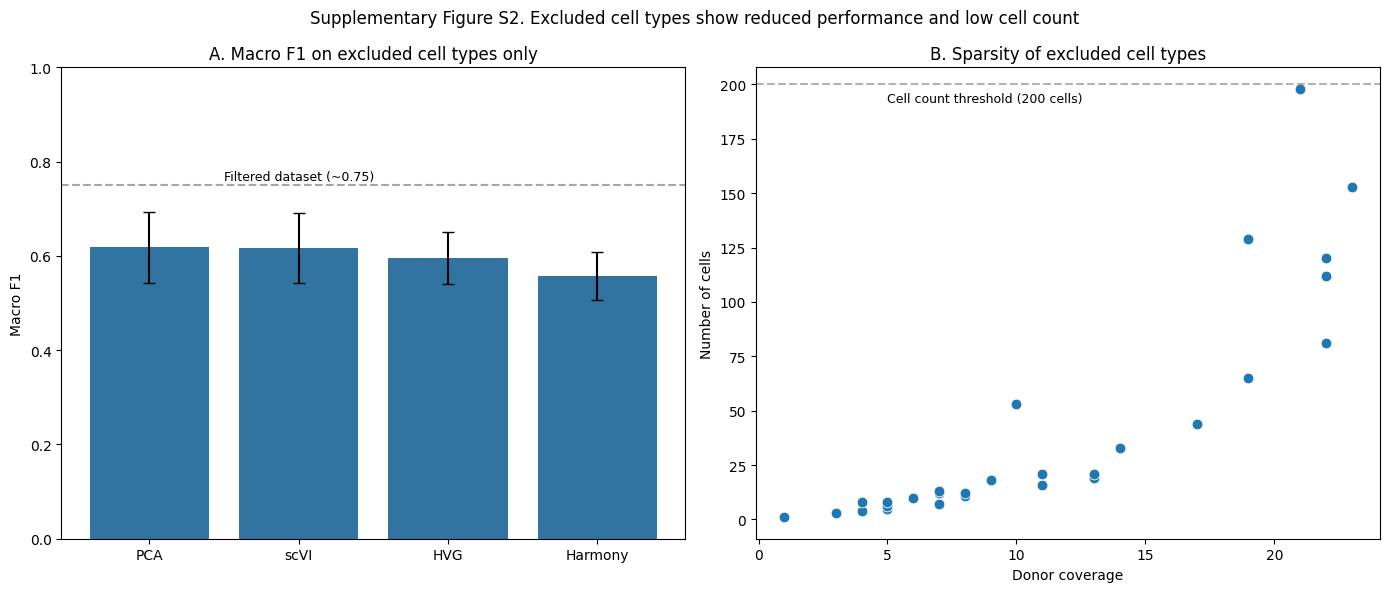

In [47]:
# -------------------------
# supplementary figure
# Panel A = macro F1
# Panel B = sparsity of excluded cell types
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A
plot_df = metrics_excluded.copy()
plot_df["representation"] = plot_df["representation"].replace({
    "hvg": "HVG",
    "X_pca": "PCA",
    "X_harmony": "Harmony",
    "X_scVI": "scVI",
})

sns.barplot(
    data=plot_df,
    x="representation",
    y="macro_f1_mean",
    ax=axes[0]
)

axes[0].errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["macro_f1_mean"],
    yerr=plot_df["macro_f1_std"],
    fmt="none",
    capsize=4,
    color="black",
)

axes[0].axhline(0.75, linestyle="--", color="gray", alpha=0.7)
axes[0].text(0.5, 0.76, "Filtered dataset (~0.75)", fontsize=9)

axes[0].set_title("A. Macro F1 on excluded cell types only")
axes[0].set_xlabel("")
axes[0].set_ylabel("Macro F1")
axes[0].set_ylim(0, 1)


# Panel B: sparsity plot
sns.scatterplot(
    data=sparsity_df,
    x="n_donors",
    y="n_cells",
    ax=axes[1],
    s=60,
)

axes[1].text(
    5, 192,
    "Cell count threshold (200 cells)",
    fontsize=9,
)

axes[1].axhline(200, linestyle="--", color="gray", alpha=0.6)
axes[1].set_xlabel("Donor coverage")
axes[1].set_ylabel("Number of cells")
axes[1].set_title("B. Sparsity of excluded cell types")

fig.suptitle("Supplementary Figure S2. Excluded cell types show reduced performance and low cell count", fontsize=12)
plt.tight_layout()
plt.savefig("results/figures/supp_excluded_celltypes_figure.png", dpi=300, bbox_inches="tight")
plt.show()

2. Supplementary Figure: Using Generalized Linear Mixed Models - account donor as a random effect

In [32]:
# additional helper functions needed for GLMMs
def run_random_split_logreg_with_metadata(
    adata,
    rep_name,
    celltype_col=CELLTYPE_COL,
    donor_col=DONOR_COL,
    site_col=BATCH_COL,
    test_size=0.2,
    random_state=RANDOM_STATE,
):
    X_rep = get_representation(adata, rep_name)
    obs = adata.obs.copy()

    y = obs[celltype_col].astype(str)
    counts = y.value_counts()
    keep_labels = counts[counts >= 2].index
    keep_mask = y.isin(keep_labels)

    X_rep = X_rep[keep_mask.to_numpy()]
    obs = obs.loc[keep_mask].copy()
    y = obs[celltype_col].astype(str).to_numpy()

    idx = np.arange(len(y))

    idx_train, idx_test = train_test_split(
        idx,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    X_train_rep = X_rep[idx_train]
    X_test_rep = X_rep[idx_test]

    y_train = y[idx_train]
    y_test = y[idx_test]

    obs_train = obs.iloc[idx_train].copy()
    obs_test = obs.iloc[idx_test].copy()

    scaler = StandardScaler()
    X_train_rep = scaler.fit_transform(X_train_rep)
    X_test_rep = scaler.transform(X_test_rep)

    clf = LogisticRegression(
        max_iter=5000,
        random_state=random_state,
        n_jobs=-1,
    )
    clf.fit(X_train_rep, y_train)
    y_pred = clf.predict(X_test_rep)

    pred_df = obs_test[[donor_col, site_col]].copy()
    pred_df["y_true"] = y_test
    pred_df["y_pred"] = y_pred
    pred_df["correct"] = (pred_df["y_true"] == pred_df["y_pred"]).astype(int)
    pred_df["scheme"] = "random"
    pred_df["representation"] = rep_name
    pred_df["split_id"] = f"random_{random_state}"

    return pred_df.reset_index(drop=True)

# modify log reg function to adapt with metadata for GLMMS.
def run_donor_split_logreg_with_metadata(
    adata,
    rep_name,
    train_donors,
    test_donors,
    celltype_col=CELLTYPE_COL,
    donor_col=DONOR_COL,
    site_col=BATCH_COL,
    random_state=RANDOM_STATE,
):
    obs = adata.obs.copy()
    X_rep = get_representation(adata, rep_name)

    train_mask = obs[donor_col].astype(str).isin(pd.Series(train_donors).astype(str))
    test_mask = obs[donor_col].astype(str).isin(pd.Series(test_donors).astype(str))

    X_train_rep = X_rep[train_mask.to_numpy()]
    X_test_rep = X_rep[test_mask.to_numpy()]

    y_train = obs.loc[train_mask, celltype_col].astype(str).to_numpy()
    y_test = obs.loc[test_mask, celltype_col].astype(str).to_numpy()

    obs_train = obs.loc[train_mask].copy()
    obs_test = obs.loc[test_mask].copy()

    train_counts = pd.Series(y_train).value_counts()
    keep_train_labels = train_counts[train_counts >= 2].index

    keep_train_mask = pd.Series(y_train).isin(keep_train_labels).to_numpy()
    X_train_rep = X_train_rep[keep_train_mask]
    y_train = y_train[keep_train_mask]
    obs_train = obs_train.loc[keep_train_mask].copy()

    y_test, X_test_rep, obs_test = restrict_to_train_labels(
        y_train=y_train,
        y_test=y_test,
        X_test=X_test_rep,
        obs_test=obs_test,
    )

    if len(y_test) == 0:
        raise ValueError("No valid test cells remain after restricting to training labels.")

    scaler = StandardScaler()
    X_train_rep = scaler.fit_transform(X_train_rep)
    X_test_rep = scaler.transform(X_test_rep)

    clf = LogisticRegression(
        max_iter=5000,
        random_state=random_state,
        n_jobs=-1,
    )
    clf.fit(X_train_rep, y_train)
    y_pred = clf.predict(X_test_rep)

    pred_df = obs_test[[donor_col, site_col]].copy()
    pred_df["y_true"] = y_test
    pred_df["y_pred"] = y_pred
    pred_df["correct"] = (pred_df["y_true"] == pred_df["y_pred"]).astype(int)
    pred_df["scheme"] = "donor_held_out"
    pred_df["representation"] = rep_name

    return pred_df.reset_index(drop=True)

# fit GLMM
def fit_correctness_glmm(df_rep):
    df_rep = df_rep.copy()

    df_rep[DONOR_COL] = df_rep[DONOR_COL].astype("category")
    df_rep["scheme"] = pd.Categorical(
        df_rep["scheme"],
        categories=["donor_held_out", "random"]
    )

    formula = "correct ~ C(scheme)"
    vc_formulas = {
        "donor_re": f"0 + C({DONOR_COL})"
    }

    model = BinomialBayesMixedGLM.from_formula(
        formula,
        vc_formulas,
        df_rep,
    )
    result = model.fit_vb()

    return model, result


In [29]:
adata = sc.read_h5ad(FILTERED_DATA_PATH)

results_dir = Path("results/supp_glmm_s3")
results_dir.mkdir(parents=True, exist_ok=True)

all_pred_dfs = []

# -------------------------
# Scheme A: repeated random splits
# -------------------------
n_random_repeats = 5

for rep_label, rep_key in REPRESENTATIONS.items():
    print(f"\nRandom split pooled predictions for {rep_label} ({rep_key})")

    for repeat in range(n_random_repeats):
        seed = RANDOM_STATE + repeat

        pred_df = run_random_split_logreg_with_metadata(
            adata=adata,
            rep_name=rep_key,
            random_state=seed,
        )

        pred_df["rep_label"] = rep_label
        pred_df["split_id"] = f"random_{repeat+1}"
        all_pred_dfs.append(pred_df)

# -------------------------
# Scheme B: donor-held-out folds
# -------------------------
donor_folds = make_donor_folds(
    adata,
    donor_col=DONOR_COL,
    n_folds=5,
    random_state=RANDOM_STATE,
)

for rep_label, rep_key in REPRESENTATIONS.items():
    print(f"\nDonor-held-out pooled predictions for {rep_label} ({rep_key})")

    for fold_idx in range(len(donor_folds)):
        test_donors = donor_folds[fold_idx]
        train_donors = np.concatenate(
            [donor_folds[j] for j in range(len(donor_folds)) if j != fold_idx]
        )

        pred_df = run_donor_split_logreg_with_metadata(
            adata=adata,
            rep_name=rep_key,
            train_donors=train_donors,
            test_donors=test_donors,
            random_state=RANDOM_STATE,
        )

        pred_df["rep_label"] = rep_label
        pred_df["split_id"] = f"fold_{fold_idx+1}"
        all_pred_dfs.append(pred_df)

glmm_input_df = pd.concat(all_pred_dfs, ignore_index=True)
glmm_input_df.to_csv(results_dir / "glmm_input_predictions.csv", index=False)

print(glmm_input_df.head())
print(glmm_input_df.shape)


Random split pooled predictions for hvg (hvg)

Random split pooled predictions for pca (X_pca)

Random split pooled predictions for harmony (X_harmony)

Random split pooled predictions for scvi (X_scVI)

Donor-held-out pooled predictions for hvg (hvg)

Donor-held-out pooled predictions for pca (X_pca)

Donor-held-out pooled predictions for harmony (X_harmony)

Donor-held-out pooled predictions for scvi (X_scVI)
  patient_id       Site                                             y_true  \
0  MH8919226        Ncl                             CD14-positive monocyte   
1  MH8919178        Ncl                             CD14-positive monocyte   
2     CV0917  Cambridge                                   T-helper 22 cell   
3     CV0934  Cambridge  naive thymus-derived CD8-positive, alpha-beta ...   
4     CV0917  Cambridge  naive thymus-derived CD4-positive, alpha-beta ...   

                                              y_pred  correct  scheme  \
0                             CD14-positiv

In [33]:
def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

glmm_summary_rows = []

for rep_label in REPRESENTATIONS.keys():
    df_rep = glmm_input_df.loc[glmm_input_df["rep_label"] == rep_label].copy()

    print(f"Fitting GLMM for {rep_label}...")
    model, result = fit_correctness_glmm(df_rep)

    print(result.summary())

    fe_names = model.exog_names
    fe_mean = pd.Series(result.fe_mean, index=fe_names)
    fe_sd = pd.Series(result.fe_sd, index=fe_names)

    # baseline = donor_held_out + reference site
    eta_donor = fe_mean["Intercept"]
    p_donor = logistic(eta_donor)

    # random effect coefficient name usually looks like C(scheme)[T.random]
    scheme_coef_name = [x for x in fe_names if "C(scheme)" in x and "random" in x][0]
    eta_random = fe_mean["Intercept"] + fe_mean[scheme_coef_name]
    p_random = logistic(eta_random)

    glmm_summary_rows.append({
        "representation": rep_label,
        "scheme": "donor_held_out",
        "pred_prob_correct": p_donor,
        "coef_intercept": fe_mean["Intercept"],
        "coef_scheme_random": fe_mean.get(scheme_coef_name, np.nan),
    })

    glmm_summary_rows.append({
        "representation": rep_label,
        "scheme": "random",
        "pred_prob_correct": p_random,
        "coef_intercept": fe_mean["Intercept"],
        "coef_scheme_random": fe_mean.get(scheme_coef_name, np.nan),
    })

glmm_summary_df = pd.DataFrame(glmm_summary_rows)
glmm_summary_df.to_csv(results_dir / "glmm_predicted_probabilities.csv", index=False)
glmm_summary_df

Fitting GLMM for hvg...
                    Binomial Mixed GLM Results
                    Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------
Intercept              M     1.5004   0.0182                      
C(scheme)[T.random]    M     0.1164   0.0262                      
donor_re               V    -0.5418   0.1476 0.582   0.433   0.781
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations
Fitting GLMM for pca...
                    Binomial Mixed GLM Results
                    Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------
Intercept              M     1.5716   0.0185                      
C(scheme)[T.random]    M     0.0939   0.0266                      
donor_re               V    -0.5540   0.1476 0.575   0.428   0.772
Parameter types are mean structure (M) and variance structure (

,representation,scheme,pred_prob_correct,coef_intercept,coef_scheme_random
0,hvg,donor_held_out,0.817639,1.500436,0.116362
1,hvg,random,0.834353,1.500436,0.116362
2,pca,donor_held_out,0.828005,1.571556,0.093893
3,pca,random,0.840968,1.571556,0.093893
4,harmony,donor_held_out,0.798633,1.377775,0.054844
5,harmony,random,0.807309,1.377775,0.054844
6,scvi,donor_held_out,0.802715,1.403353,0.104258
7,scvi,random,0.818707,1.403353,0.104258


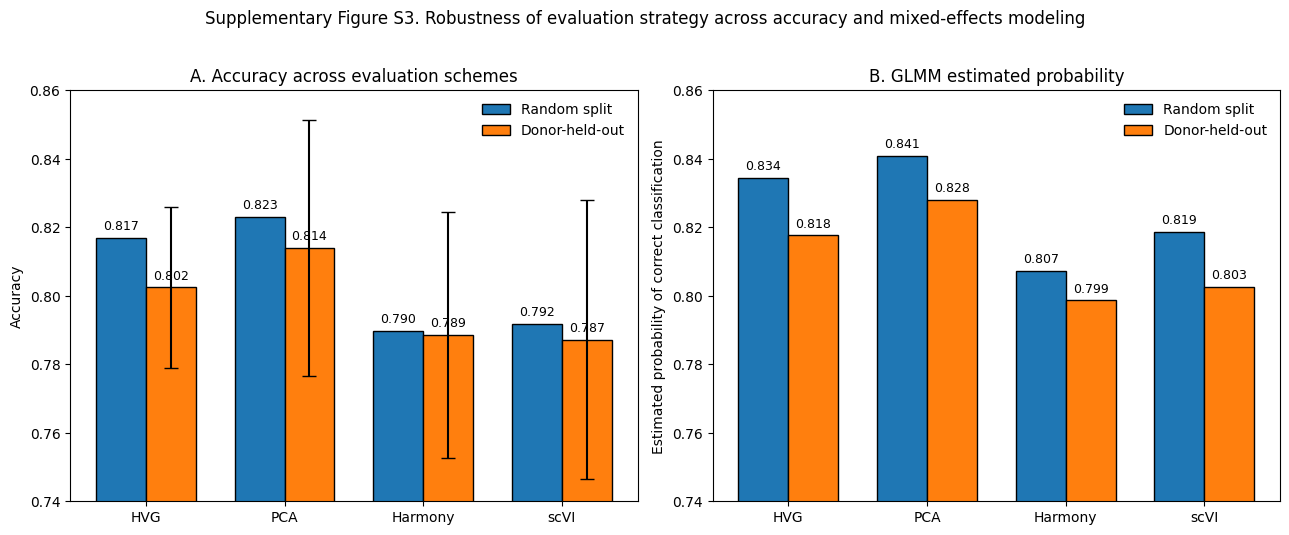

In [49]:
# -------------------------
# plot S3 (match Figure 2B style)
# -------------------------
x = np.arange(len(rep_order))
width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# =========================
# Panel A: Accuracy
# =========================

random_df = (
    acc_plot_df[acc_plot_df["scheme"] == "Random split"]
    .set_index("representation")
    .loc[rep_order]
)

donor_df = (
    acc_plot_df[acc_plot_df["scheme"] == "Donor-held-out"]
    .set_index("representation")
    .loc[rep_order]
)

bars_random = axes[0].bar(
    x - width/2,
    random_df["accuracy"],
    width,
    label="Random split",
    edgecolor="black"
)

bars_donor = axes[0].bar(
    x + width/2,
    donor_df["accuracy"],
    width,
    yerr=donor_df["accuracy_sd"],
    capsize=5,
    label="Donor-held-out",
    edgecolor="black"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(rep_order)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("A. Accuracy across evaluation schemes")
axes[0].set_ylim(0.74, 0.86)
axes[0].legend(frameon=False)

# value labels
for bars in [bars_random, bars_donor]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            h + 0.0015,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# =========================
# Panel B: GLMM probability
# =========================

random_glmm = (
    glmm_plot_df[glmm_plot_df["scheme"] == "Random split"]
    .set_index("representation")
    .loc[rep_order]
)

donor_glmm = (
    glmm_plot_df[glmm_plot_df["scheme"] == "Donor-held-out"]
    .set_index("representation")
    .loc[rep_order]
)

bars_random = axes[1].bar(
    x - width/2,
    random_glmm["pred_prob_correct"],
    width,
    label="Random split",
    edgecolor="black"
)

bars_donor = axes[1].bar(
    x + width/2,
    donor_glmm["pred_prob_correct"],
    width,
    label="Donor-held-out",
    edgecolor="black"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(rep_order)
axes[1].set_ylabel("Estimated probability of correct classification")
axes[1].set_title("B. GLMM estimated probability")
axes[1].set_ylim(0.74, 0.86)
axes[1].legend(frameon=False)

# value labels
for bars in [bars_random, bars_donor]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            h + 0.0015,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# -------------------------
# final
# -------------------------
fig.suptitle(
    "Supplementary Figure S3. Robustness of evaluation strategy across accuracy and mixed-effects modeling",
    y=1.02
)

plt.tight_layout()
plt.savefig("results/figures/supp_figure_s3_combined.png", dpi=300, bbox_inches="tight")
plt.show()